# 01 - Descarga de datos financieros

## Objetivo

En este notebook descargaremos datos históricos de acciones utilizando la librería `yfinance`.

Estos datos serán la base para construir un portafolio óptimo mediante la Teoría Moderna de Portafolios de Harry Markowitz y posteriormente compararlo con el índice S&P 500.

### Activos seleccionados

| Ticker | Empresa | Sector |
|---------|----------|---------|
| AAPL | Apple | Tecnología |
| MSFT | Microsoft | Tecnología |
| NVDA | NVIDIA | Tecnología |
| KO | Coca-Cola | Consumo |
| WMT | Walmart | Consumo |
| JPM | JPMorgan Chase | Financiero |
| V | Visa | Financiero |
| JNJ | Johnson & Johnson | Salud |
| XOM | Exxon Mobil | Energía |
| CAT | Caterpillar | Industrial |
| SPY | ETF S&P 500 | Benchmark |

In [ ]:
# =====================================================
# Importación de librerías
# =====================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.express as px

# Configuración para visualizar mejor las tablas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


Matplotlib is building the font cache; this may take a moment.


✅ Librerías cargadas correctamente.


In [21]:
from pathlib import Path

# Ruta donde se guardarán las figuras
FIGURES_DIR = Path("../reports/figures")

# Crear la carpeta si no existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# =====================================================
# Lista de activos
# =====================================================

tickers = [
    "AAPL",
    "MSFT",
    "NVDA",
    "KO",
    "WMT",
    "JPM",
    "V",
    "JNJ",
    "XOM",
    "CAT",
    "SPY"
]

print(f"Número de activos: {len(tickers)}")
print(tickers)

Número de activos: 11
['AAPL', 'MSFT', 'NVDA', 'KO', 'WMT', 'JPM', 'V', 'JNJ', 'XOM', 'CAT', 'SPY']


In [ ]:
# =====================================================
# Descarga de datos desde Yahoo Finance
# =====================================================

data = yf.download(
    tickers=tickers,
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=False,
    progress=False
)

✅ Datos descargados correctamente.


In [4]:
# Primeras filas del conjunto de datos
data.head()

Price       Adj Close                                                                                             \
Ticker           AAPL         CAT         JNJ        JPM         KO       MSFT      NVDA         SPY           V   
Date                                                                                                               
2018-01-02  40.267075  131.050781  110.130821  85.516022  35.024223  78.699913  4.922528  235.954285  107.888245   
2018-01-03  40.260071  131.251068  111.182854  85.603157  34.947311  79.066170  5.246499  237.446808  108.962318   
2018-01-04  40.447060  133.053604  111.174957  86.829475  35.439533  79.762077  5.274155  238.447525  109.367470   
2018-01-05  40.907566  135.156540  112.092506  86.272079  35.431831  80.750961  5.318851  240.036545  111.986717   
2018-01-08  40.755638  138.553009  112.234856  86.399467  35.378002  80.833366  5.481824  240.475479  112.438950   

Price                                 Close                                                                     \
Ticker            WMT        XOM       AAPL         CAT         JNJ         JPM         KO       MSFT     NVDA   
Date                                                                                                             
2018-01-02  28.800240  58.185486  43.064999  157.039993  139.229996  107.949997  45.540001  85.949997  4.98375   
2018-01-03  29.051468  59.328255  43.057499  157.279999  140.559998  108.059998  45.439999  86.349998  5.31175   
2018-01-04  29.077749  59.410378  43.257500  159.440002  140.550003  109.040001  46.080002  87.110001  5.33975   
2018-01-05  29.250099  59.362476  43.750000  161.960007  141.710007  108.339996  46.070000  88.190002  5.38500   
2018-01-08  29.682447  59.629353  43.587502  166.029999  141.889999  108.500000  46.000000  88.279999  5.55000   

Price                                                          High                                                 \
Ticker             SPY           V        WMT        XOM       AAPL         CAT         JNJ         JPM         KO   
Date                                                                                                                 
2018-01-02  268.769989  114.510002  32.863335  85.029999  43.075001  159.389999  139.949997  108.019997  45.939999   
2018-01-03  270.470001  115.650002  33.150002  86.699997  43.637501  157.490005  140.679993  108.489998  45.689999   
2018-01-04  271.609985  116.080002  33.180000  86.820000  43.367500  159.580002  141.139999  110.029999  46.220001   
2018-01-05  273.420013  118.860001  33.376667  86.750000  43.842499  162.050003  141.820007  109.550003  46.200001   
2018-01-08  273.920013  119.339996  33.869999  87.139999  43.902500  166.429993  142.000000  108.680000  46.099998   

Price                                                                               Low                          \
Ticker           MSFT     NVDA         SPY           V        WMT        XOM       AAPL         CAT         JNJ   
Date                                                                                                              
2018-01-02  86.309998  4.98750  268.809998  115.080002  33.263332  85.199997  42.314999  156.029999  138.720001   
2018-01-03  86.510002  5.34250  270.640015  115.790001  33.333332  86.970001  42.990002  155.399994  138.899994   
2018-01-04  87.660004  5.45125  272.160004  117.360001  33.259998  87.220001  43.020000  157.020004  140.220001   
2018-01-05  88.410004  5.42275  273.559998  119.000000  33.459999  86.879997  43.262501  159.639999  140.279999   
2018-01-08  88.580002  5.62500  274.100006  120.480003  33.916668  87.150002  43.482498  162.550003  140.919998   

Price                                                                                                     Open  \
Ticker             JPM         KO       MSFT     NVDA         SPY           V        WMT        XOM       AAPL   
Date                                                            

In [5]:
# Información general del DataFrame

data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1761 entries, 2018-01-02 to 2024-12-31
Data columns (total 66 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1761 non-null   float64
 1   (Adj Close, CAT)   1761 non-null   float64
 2   (Adj Close, JNJ)   1761 non-null   float64
 3   (Adj Close, JPM)   1761 non-null   float64
 4   (Adj Close, KO)    1761 non-null   float64
 5   (Adj Close, MSFT)  1761 non-null   float64
 6   (Adj Close, NVDA)  1761 non-null   float64
 7   (Adj Close, SPY)   1761 non-null   float64
 8   (Adj Close, V)     1761 non-null   float64
 9   (Adj Close, WMT)   1761 non-null   float64
 10  (Adj Close, XOM)   1761 non-null   float64
 11  (Close, AAPL)      1761 non-null   float64
 12  (Close, CAT)       1761 non-null   float64
 13  (Close, JNJ)       1761 non-null   float64
 14  (Close, JPM)       1761 non-null   float64
 15  (Close, KO)        1761 non-null   float64
 16  (Close, MSFT)    

In [6]:
type(data)


pandas.DataFrame

In [7]:
# Dimensiones

data.shape

(1761, 66)

In [10]:
data.isna().sum()

Price      Ticker
Adj Close  AAPL      0
           CAT       0
           JNJ       0
           JPM       0
           KO        0
                    ..
Volume     NVDA      0
           SPY       0
           V         0
           WMT       0
           XOM       0
Length: 66, dtype: int64

In [11]:
adj_close = data["Adj Close"]

adj_close.head()

Ticker,AAPL,CAT,JNJ,JPM,KO,MSFT,NVDA,SPY,V,WMT,XOM
Date,,,,,,,,,,,
2018-01-02,40.267075,131.050781,110.130821,85.516022,35.024223,78.699913,4.922528,235.954285,107.888245,28.800240,58.185486
2018-01-03,40.260071,131.251068,111.182854,85.603157,34.947311,79.066170,5.246499,237.446808,108.962318,29.051468,59.328255
2018-01-04,40.447060,133.053604,111.174957,86.829475,35.439533,79.762077,5.274155,238.447525,109.367470,29.077749,59.410378
2018-01-05,40.907566,135.156540,112.092506,86.272079,35.431831,80.750961,5.318851,240.036545,111.986717,29.250099,59.362476
2018-01-08,40.755638,138.553009,112.234856,86.399467,35.378002,80.833366,5.481824,240.475479,112.438950,29.682447,59.629353


In [13]:
# Guardar los precios ajustados

adj_close.to_csv("../data/raw/adj_close.csv")

In [14]:
adj_close = pd.read_csv(
    "../data/raw/adj_close.csv",
    index_col=0,
    parse_dates=True
)

adj_close.head()

,AAPL,CAT,JNJ,JPM,KO,MSFT,NVDA,SPY,V,WMT,XOM
Date,,,,,,,,,,,
2018-01-02,40.267075,131.050781,110.130821,85.516022,35.024223,78.699913,4.922528,235.954285,107.888245,28.800240,58.185486
2018-01-03,40.260071,131.251068,111.182854,85.603157,34.947311,79.066170,5.246499,237.446808,108.962318,29.051468,59.328255
2018-01-04,40.447060,133.053604,111.174957,86.829475,35.439533,79.762077,5.274155,238.447525,109.367470,29.077749,59.410378
2018-01-05,40.907566,135.156540,112.092506,86.272079,35.431831,80.750961,5.318851,240.036545,111.986717,29.250099,59.362476
2018-01-08,40.755638,138.553009,112.234856,86.399467,35.378002,80.833366,5.481824,240.475479,112.438950,29.682447,59.629353


In [16]:
# Rendimientos diarios

returns = adj_close.pct_change()
returns = returns.dropna()

returns.head()

,AAPL,CAT,JNJ,JPM,KO,MSFT,NVDA,SPY,V,WMT,XOM
Date,,,,,,,,,,,
2018-01-03,-0.000174,0.001528,0.009553,0.001019,-0.002196,0.004654,0.065814,0.006325,0.009955,0.008723,0.019640
2018-01-04,0.004645,0.013733,-0.000071,0.014326,0.014085,0.008802,0.005271,0.004214,0.003718,0.000905,0.001384
2018-01-05,0.011385,0.015805,0.008253,-0.006419,-0.000217,0.012398,0.008475,0.006664,0.023949,0.005927,-0.000806
2018-01-08,-0.003714,0.025130,0.001270,0.001477,-0.001519,0.001020,0.030641,0.001829,0.004038,0.014781,0.004496
2018-01-09,-0.000115,0.002409,0.015857,0.005069,0.005000,-0.000680,-0.000270,0.002264,-0.001927,-0.012007,-0.004246


In [17]:
returns.to_csv("../data/processed/daily_returns.csv")

In [18]:
returns.describe()

,AAPL,CAT,JNJ,JPM,KO,MSFT,NVDA,SPY,V,WMT,XOM
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000
mean,0.001220,0.000768,0.000207,0.000739,0.000379,0.001113,0.002405,0.000583,0.000742,0.000736,0.000512
std,0.019242,0.020014,0.012325,0.018640,0.012315,0.018197,0.032465,0.012259,0.016586,0.013734,0.019523
min,-0.128647,-0.142822,-0.100379,-0.149649,-0.096725,-0.147391,-0.187559,-0.109423,-0.135472,-0.113758,-0.122248
25%,-0.008034,-0.009651,-0.005477,-0.007769,-0.005156,-0.007511,-0.015233,-0.004396,-0.007132,-0.005576,-0.009743
50%,0.001276,0.000731,0.000403,0.000669,0.000694,0.001281,0.002863,0.000787,0.001452,0.000833,0.000249
75%,0.011506,0.011693,0.006078,0.009117,0.006120,0.010731,0.019927,0.006688,0.008642,0.007240,0.010696
max,0.119808,0.103321,0.079977,0.180125,0.064795,0.142169,0.243696,0.090603,0.138427,0.117085,0.126868


In [19]:
cumulative_returns = (1 + returns).cumprod()

cumulative_returns.head()

,AAPL,CAT,JNJ,JPM,KO,MSFT,NVDA,SPY,V,WMT,XOM
Date,,,,,,,,,,,
2018-01-03,0.999826,1.001528,1.009553,1.001019,0.997804,1.004654,1.065814,1.006325,1.009955,1.008723,1.019640
2018-01-04,1.004470,1.015283,1.009481,1.015359,1.011858,1.013496,1.071432,1.010567,1.013711,1.009636,1.021051
2018-01-05,1.015906,1.031330,1.017812,1.008841,1.011638,1.026062,1.080512,1.017301,1.037988,1.015620,1.020228
2018-01-08,1.012133,1.057247,1.019105,1.010331,1.010101,1.027109,1.113620,1.019161,1.042180,1.030632,1.024815
2018-01-09,1.012017,1.059794,1.035265,1.015452,1.015152,1.026411,1.113319,1.021468,1.040171,1.018257,1.020463


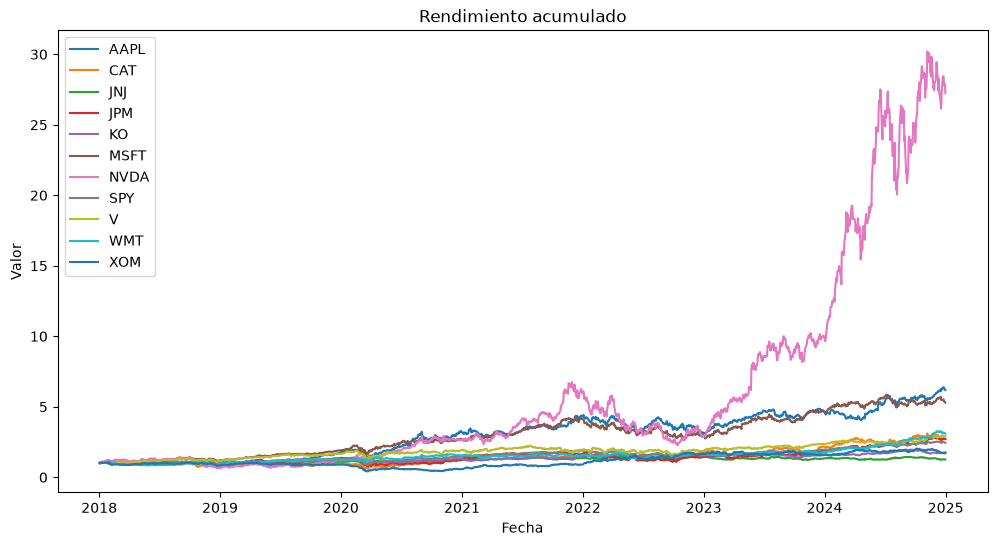

In [20]:
plt.figure(figsize=(12,6))

for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index,
             cumulative_returns[column],
             label=column)

plt.title("Rendimiento acumulado")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.show()